In [1]:
# Core data handling
import pandas as pd
import numpy as np


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Model persistence
import joblib


# Train/test split, cross-validation, hyperparameter tuning
from sklearn.model_selection import (
    train_test_split,
    KFold,
    GroupKFold,
    cross_val_score,
    GridSearchCV
)


# Preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Models
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
    StackingRegressor
)
from sklearn.multioutput import MultiOutputRegressor
import xgboost as xgb


# Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import os

# Suppress convergence/future warnings for cleaner output (optional)
import warnings
warnings.filterwarnings('ignore')

## Data Pipeline

In [2]:
CONSTRUCTION_DATA = "/Users/sanjib700/Desktop/My_Projects/1800/Data"

def load_construction_data(construction_data_path=CONSTRUCTION_DATA):
    csv_path = os.path.join(construction_data_path, "raw_data_a.csv")
    
    # Load the data
    df = pd.read_csv(csv_path)
    
    # Define columns to keep (with possible variations in naming)
    columns_to_keep = ['Date', 'Partner', 'Offer', 'Leads','Agent Conversion Pct', 'Avg Cost', 'Sum Cost', 'Sum Scrub Cost', 'Avg Scrub Cost',
                      'Sum Revenue', 'Avg Revenue', 'Avg Income', 'Sum Income']
    
    # Print original columns for debugging
    print(f"Original columns: {df.columns.tolist()}")
    
    # Try to find columns with case-insensitive matching
    selected_columns = []
    for col in columns_to_keep:
        # Try exact match first
        if col in df.columns:
            selected_columns.append(col)
        else:
            # Try case-insensitive match
            matches = [c for c in df.columns if c.lower() == col.lower()]
            if matches:
                selected_columns.append(matches[0])
                print(f"ℹ️ Using '{matches[0]}' instead of '{col}'")
            else:
                print(f"⚠️ Column '{col}' not found")
    
    # Keep only selected columns
    if selected_columns:
        print(f"✅ Extracted {len(selected_columns)} columns")
        return df[selected_columns]
    else:
        raise ValueError("No matching columns found!")
data = load_construction_data()
data.info()

Original columns: ['X', 'Data Status', 'Date', 'Partner', 'Offer', 'Leads', 'Exclusive Auto Converted', 'Exclusive Auto Pct Gross', 'Agent Conversion Eligible', 'Agent Converted', 'Agent Conversion Pct', 'Avg Rev Per Agent Conv', 'Avg Cost', 'Avg Scrub Cost', 'Sum Cost', 'Sum Scrub Cost', 'Average Auto Revenue', 'Sum Auto Revenue', 'Avg Agent Revenue', 'Sum of Agent Revenue', 'Avg Revenue', 'Sum Revenue', 'Avg Income', 'Sum Income', 'Unnamed: 24']
✅ Extracted 13 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9796 entries, 0 to 9795
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  9796 non-null   object 
 1   Partner               9796 non-null   object 
 2   Offer                 9795 non-null   object 
 3   Leads                 9796 non-null   int64  
 4   Agent Conversion Pct  9796 non-null   float64
 5   Avg Cost              9796 non-null   float64
 6   Sum C

## Exploratory Data Analysis (EDA)

### 1.1 Basic structure and shape

In [3]:
print("Shape:", data.shape)
print("\nData types:\n", data.dtypes)
print("\nFirst 5 rows:")
data.head()

Shape: (9796, 13)

Data types:
 Date                     object
Partner                  object
Offer                    object
Leads                     int64
Agent Conversion Pct    float64
Avg Cost                float64
Sum Cost                 object
Sum Scrub Cost           object
Avg Scrub Cost          float64
Sum Revenue              object
Avg Revenue             float64
Avg Income              float64
Sum Income               object
dtype: object

First 5 rows:


,Date,Partner,Offer,Leads,Agent Conversion Pct,Avg Cost,Sum Cost,Sum Scrub Cost,Avg Scrub Cost,Sum Revenue,Avg Revenue,Avg Income,Sum Income
0,1/1/22,Partner_01,Offer_01,18,27.78,3.06,55,41.25,2.29,126,7.00,4.71,84.75
1,1/1/22,Partner_01,Offer_02,7,0.00,3.00,21,15.75,2.25,21,3.00,0.75,5.25
2,1/1/22,Partner_01,Offer_03,28,17.86,2.00,56,42,1.50,85,3.04,1.54,43
3,1/1/22,Partner_01,Offer_04,177,0.00,11.79,2087.17,1564.97,8.84,3894,22.00,13.16,2329.03
4,1/1/22,Partner_01,Offer_05,4,0.00,2.00,8,6,1.50,0,0.00,-1.50,-6


### 1.2 Missing values overview

In [4]:
missing = data.isna().sum()
missing_pct = (missing / len(data) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

             Missing Count  Missing %
Offer                    1       0.01
Sum Revenue              1       0.01
Avg Revenue              1       0.01
Avg Income               1       0.01
Sum Income               1       0.01


### 1.3 Unique value counts for categorical columns

In [5]:
for col in ['Partner', 'Offer']:
    print(f"\n{col}: {data[col].nunique()} unique values")
    print(data[col].value_counts().head(10))


Partner: 77 unique values
Partner
Partner_27    1020
Partner_31     967
Partner_54     751
Partner_02     708
Partner_24     675
Partner_26     660
Partner_25     655
Partner_03     576
Partner_17     399
Partner_11     395
Name: count, dtype: int64

Offer: 40 unique values
Offer
Offer_09    908
Offer_01    729
Offer_02    507
Offer_06    502
Offer_08    435
Offer_03    427
Offer_16    416
Offer_15    371
Offer_17    367
Offer_20    363
Name: count, dtype: int64


### 1.4 Date range coverage

In [6]:
data['Date_parsed'] = pd.to_datetime(data['Date'], format='%m/%d/%y', errors='coerce')
print("Date range:", data['Date_parsed'].min(), "to", data['Date_parsed'].max())
print("Rows with unparseable dates:", data['Date_parsed'].isna().sum())

Date range: 2022-01-01 00:00:00 to 2026-05-01 00:00:00
Rows with unparseable dates: 0


### 1.5 Numeric column summary stats

In [7]:
numeric_cols = ['Leads', 'Sum Cost', 'Sum Revenue', 'Sum Income', 'Avg Cost',
                 'Avg Revenue', 'Avg Income', 'Sum Scrub Cost', 'Avg Scrub Cost',
                 'Agent Conversion Pct']

# these may still be strings with commas at this raw stage — check first
for col in numeric_cols:
    if col in data.columns:
        print(f"{col}: dtype = {data[col].dtype}")

Leads: dtype = int64
Sum Cost: dtype = object
Sum Revenue: dtype = object
Sum Income: dtype = object
Avg Cost: dtype = float64
Avg Revenue: dtype = float64
Avg Income: dtype = float64
Sum Scrub Cost: dtype = object
Avg Scrub Cost: dtype = float64
Agent Conversion Pct: dtype = float64


### 1.6 Correlation heatmap between numeric columns

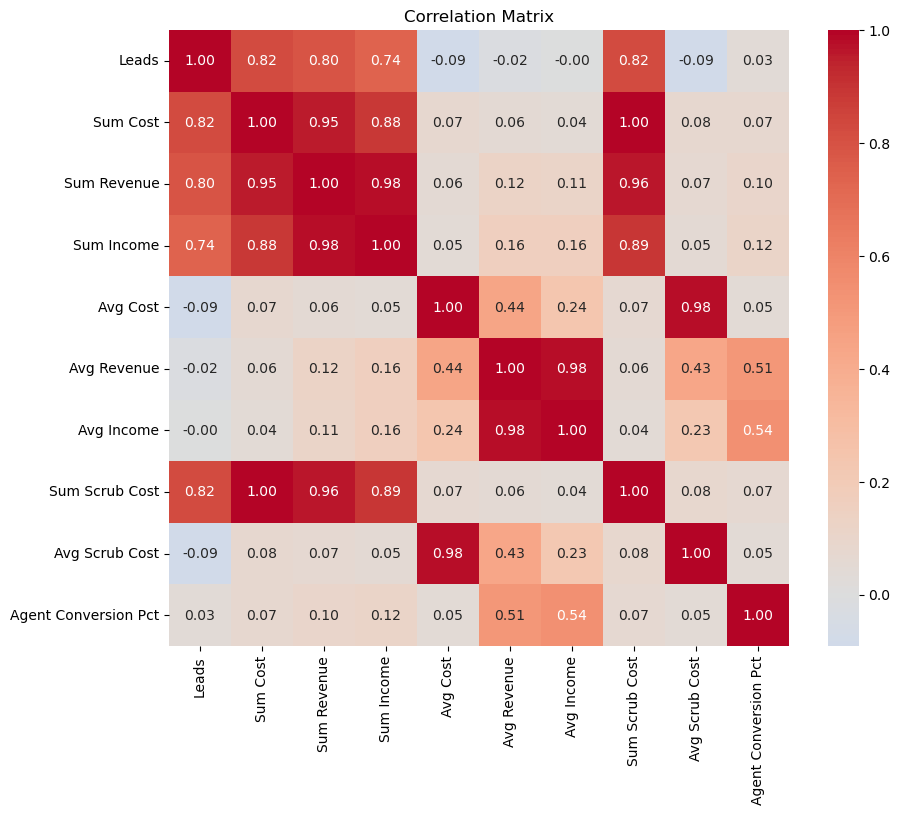

In [8]:
numeric_df = data[numeric_cols].apply(
    lambda col: pd.to_numeric(col.astype(str).str.replace(',', '', regex=False), errors='coerce')
)

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

### <span style="color:#1a5fb4">Correlation Analysis — Key Findings</span>
<hr style="border: 1px solid #cccccc; margin-top: 5px; margin-bottom: 20px;">

The correlation matrix reveals two distinct clusters of variables in the dataset, with important implications for feature selection and target predictability.

#### 1. Volume metrics are strongly interrelated (r = 0.74–1.00)

`Leads`, `Sum Cost`, `Sum Revenue`, `Sum Income`, and `Sum Scrub Cost` all correlate strongly with one another (0.74–1.00). Notably, `Sum Cost` and `Sum Scrub Cost` show a near-perfect correlation (r = 1.00), indicating scrub cost tracks total spend at a highly consistent rate. Similarly, `Sum Revenue` and `Sum Income` correlate at r = 0.98, consistent with income being derived directly from revenue net of cost.

**Implication:** These relationships explain why models achieved very high R² (>0.99) when predicting `Sum Scrub Cost` — the target is nearly a linear function of an existing feature (`Sum Cost`), rather than a genuinely independent prediction problem.

#### 2. Average/rate metrics form a separate, largely disconnected cluster

`Avg Cost`, `Avg Revenue`, `Avg Income`, and `Avg Scrub Cost` correlate strongly within their own group (0.44–0.98) but show weak or negligible correlation with the volume metrics above (typically |r| < 0.12). `Agent Conversion Pct` behaves similarly — correlating moderately with `Avg Revenue` (0.51) and `Avg Income` (0.54), but showing near-zero correlation with `Leads` (0.03), `Sum Cost` (0.07), and `Sum Income` (0.12).

**Implication:** Per-unit and rate-based metrics are driven by factors not captured in the available features (Partner, Offer, Sum Cost, Month, Year) — likely lead quality, timing, or agent-level performance. This is consistent with the near-zero R² (0.001) observed when `Agent Conversion Pct` was tested as a model target, and supports the decision to exclude it from the final feature/target set.

#### 3. Practical takeaway for modeling

Given this structure, `Leads` and `Sum Income` remain the most meaningful and genuinely predictable targets from the available features — correlated with cost (r = 0.74–0.82) but not so strongly that prediction is trivial, leaving real variance for a model to explain. `Sum Scrub Cost`, while easy to predict, offers limited standalone business value as a *forecasting* target given its near-deterministic relationship with cost already known at time of spend.

### 1.7.1 Box plots for outlier detection across key numeric columns

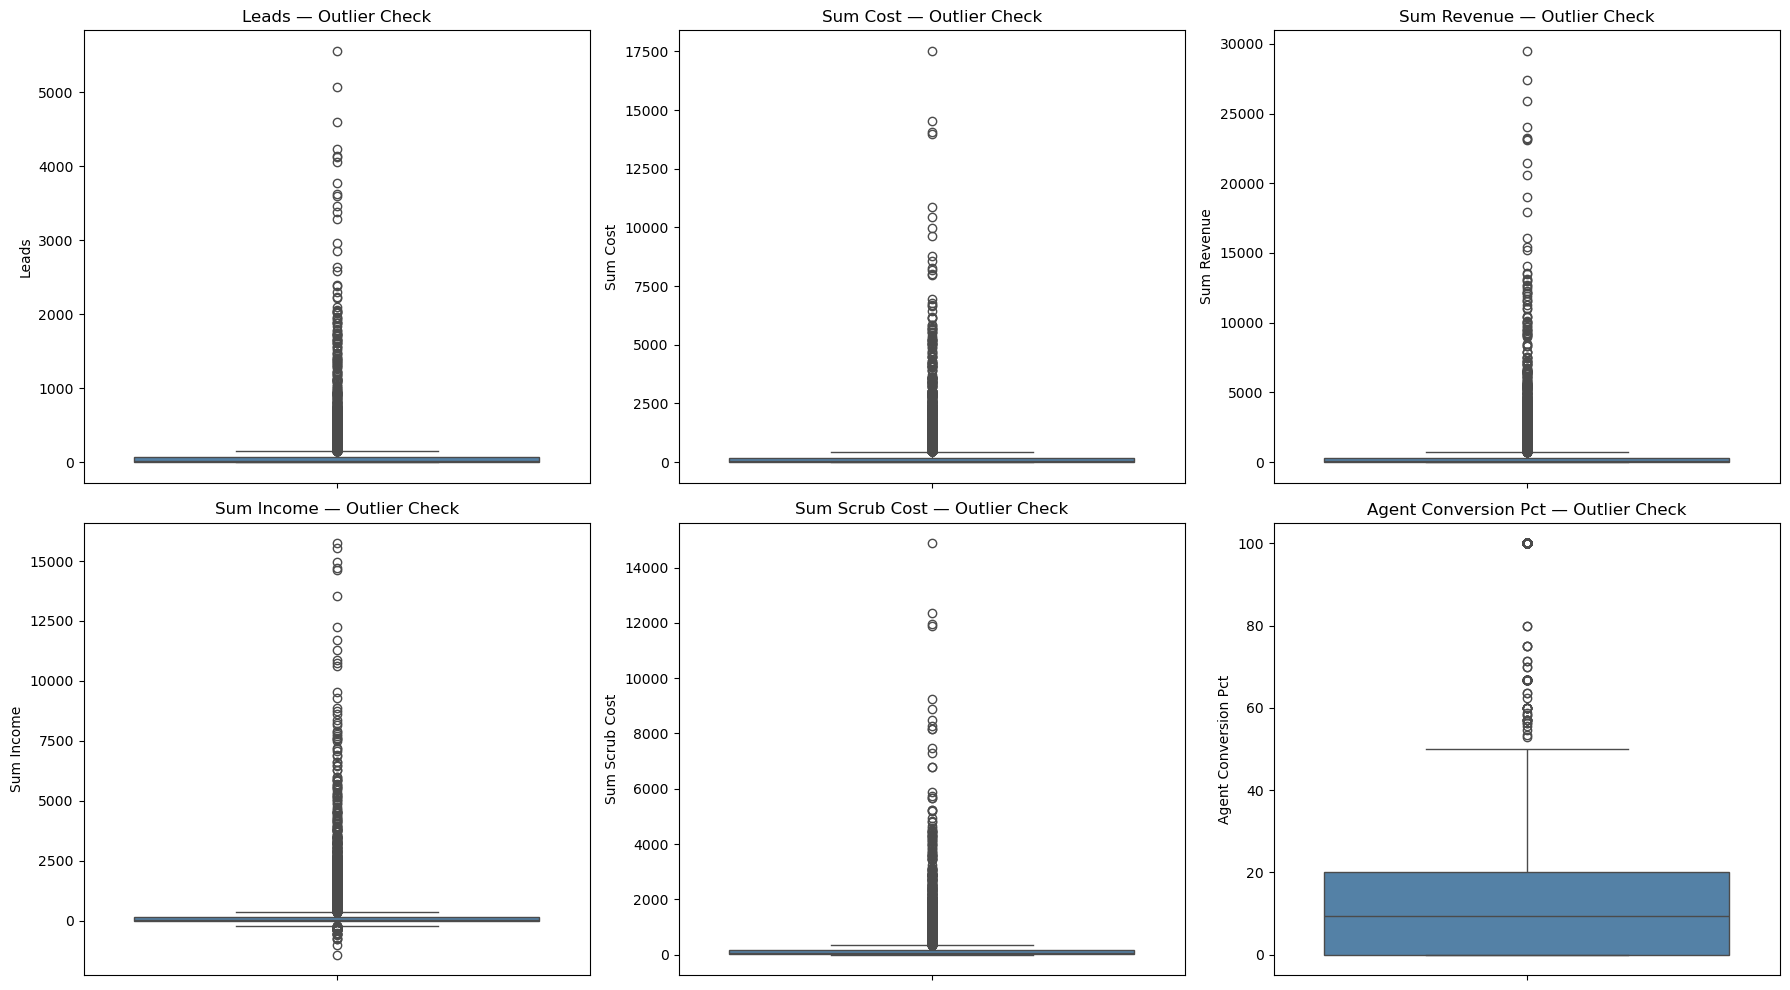

In [9]:
# Clean comma-formatted numbers first (same fix as before)
plot_cols = ['Leads', 'Sum Cost', 'Sum Revenue', 'Sum Income', 'Sum Scrub Cost', 'Agent Conversion Pct']

clean_df = data[plot_cols].apply(
    lambda col: pd.to_numeric(col.astype(str).str.replace(',', '', regex=False), errors='coerce')
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), plot_cols):
    sns.boxplot(y=clean_df[col], ax=ax, color='steelblue')
    ax.set_title(f'{col} — Outlier Check')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

### 1.7.1 Box plots for outlier detection across key numeric columns

In [10]:
outlier_summary = []

for col in plot_cols:
    Q1 = clean_df[col].quantile(0.25)
    Q3 = clean_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outliers = ((clean_df[col] < lower) | (clean_df[col] > upper)).sum()
    pct_outliers = round(n_outliers / len(clean_df) * 100, 2)
    
    outlier_summary.append({
        'Column': col,
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': n_outliers,
        'Outlier %': pct_outliers
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)

                 Column  Lower Bound  Upper Bound  Outlier Count  Outlier %
0                 Leads       -83.50       152.50           1108      11.31
1              Sum Cost      -247.25       452.08           1100      11.23
2           Sum Revenue      -446.33       743.88           1100      11.23
3            Sum Income      -236.53       375.73           1287      13.14
4        Sum Scrub Cost      -194.23       355.72           1106      11.29
5  Agent Conversion Pct       -30.00        50.00            206       2.10


### <span style="color:#1a5fb4">Outlier Detection — IQR Analysis</span>
<hr style="border: 1px solid #cccccc; margin-top: 5px; margin-bottom: 20px;">

Using the standard IQR method (1.5×IQR beyond Q1/Q3), a meaningful share of records across all volume-based metrics were flagged as statistical outliers:

| Column | Outlier % |
|---|---|
| Leads | 11.31% |
| Sum Cost | 11.23% |
| Sum Revenue | 11.23% |
| Sum Income | 13.14% |
| Sum Scrub Cost | 11.29% |
| Agent Conversion Pct | 2.10% |

#### Key observations

**1. Outlier rates are consistent (~11%) across all volume-based metrics.**
`Leads`, `Sum Cost`, `Sum Revenue`, and `Sum Scrub Cost` all show almost identical outlier proportions (11.2–11.3%). This consistency is expected given the strong correlations identified earlier (r = 0.82–1.00 between these variables) — a month with unusually high lead volume will naturally also show unusually high cost, revenue, and scrub cost, since these metrics move together. This is not four independent outlier problems; it is largely the same set of high-activity partner-months appearing across multiple correlated columns.

**2. `Sum Income` has the highest outlier rate (13.14%) and includes negative values.**
The lower bound for `Sum Income` (-236.53) being negative — and 13.14% of records falling outside the IQR range — reflects genuine business volatility: some partner-months show negative income, where scrub cost and expenses exceeded revenue. This aligns with volatility observed during data review and explains why `Sum Income` was consistently the hardest target to predict across all models tested (holdout R² 0.80–0.84, versus 0.92–0.99 for other targets).

**3. `Agent Conversion Pct` has a markedly lower outlier rate (2.10%).**
Consistent with its near-zero correlation to the volume-based metrics identified earlier, conversion percentage behaves as a distinct, more tightly-bounded variable — most values cluster close to the typical range, with comparatively few extreme swings.

#### Decision: outliers were retained, not removed

Given that ~11% of rows being flagged consistently across correlated metrics reflects genuine high-performing partner-months rather than data entry errors, these outliers were **not removed** from the dataset. Removing them would discard legitimate business variation (e.g., strong campaign months) that the model needs to learn from. Instead, model selection prioritized approaches (tree-based ensembles) that are inherently more robust to outliers than models sensitive to extreme values, such as plain Linear Regression.

### Data Cleaning 

In [11]:

# Step 1: Parse Date column (known format: mm/dd/yy)

data['Date'] = pd.to_datetime(data['Date'], format='%m/%d/%y')
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['YearMonth'] = data['Date'].dt.to_period('M')

print(f"Date range: {data['Date'].min()} to {data['Date'].max()}")



Date range: 2022-01-01 00:00:00 to 2026-05-01 00:00:00


In [12]:

# Step 2: Clean numeric columns

# Raw data contains comma-formatted numbers (e.g. "1,485.33"),
# which must be stripped before numeric coercion, or valid
# values are silently converted to NaN.

numeric_cols = ['Leads', 'Sum Cost', 'Sum Revenue', 'Sum Income', 'Avg Cost',
                 'Avg Revenue', 'Avg Income', 'Sum Scrub Cost', 'Avg Scrub Cost',
                 'Agent Conversion Pct']

for col in numeric_cols:
    if col in data.columns:
        data[col] = data[col].astype(str).str.replace(',', '', regex=False)
        data[col] = pd.to_numeric(data[col], errors='coerce')

print("Numeric conversion complete.")
print(data[numeric_cols].isna().sum())

Numeric conversion complete.
Leads                   0
Sum Cost                0
Sum Revenue             1
Sum Income              1
Avg Cost                0
Avg Revenue             1
Avg Income              1
Sum Scrub Cost          0
Avg Scrub Cost          0
Agent Conversion Pct    0
dtype: int64


In [13]:

# Step 3: Aggregate to monthly level per Partner-Offer combination

monthly_data = data.groupby(['Partner', 'Offer', 'YearMonth']).agg({
    'Leads': 'sum',
    'Sum Cost': 'sum',
    'Sum Scrub Cost': 'sum',
    'Avg Scrub Cost': 'mean',
    'Sum Revenue': 'sum',
    'Sum Income': 'sum',
    'Avg Cost': 'mean',
    'Avg Revenue': 'mean',
    'Avg Income': 'mean',
    'Agent Conversion Pct': 'mean',
    'Year': 'first',
    'Month': 'first'
}).reset_index()

monthly_data = monthly_data.sort_values(['Partner', 'Offer', 'YearMonth'])
print(f"Monthly aggregated shape: {monthly_data.shape}")

Monthly aggregated shape: (9794, 15)


In [14]:
# Step 4: Handle missing Sum Income

# These NaNs stem from source records with genuinely missing
# financial reporting (not zero-activity months) — verified by
# checking that Leads and Sum Cost were non-zero for these rows.
# Rows are dropped rather than filled, to avoid fabricating
# income data for months with real (but unreported) activity.

before = len(monthly_data)
monthly_data = monthly_data.dropna(subset=['Sum Income'])
after = len(monthly_data)
print(f"Dropped {before - after} rows with missing Sum Income ({before} -> {after})")

Dropped 0 rows with missing Sum Income (9794 -> 9794)


In [15]:
# Step 5: Filter out Partners with fewer than 2 rows

# Required for stratified train/test splitting later, and
# improves reliability — single-row partners provide no basis
# for the model to learn a stable pattern.

partner_counts = monthly_data['Partner'].value_counts()
rare_partners = partner_counts[partner_counts < 2]
print(f"Partners with fewer than 2 rows: {len(rare_partners)}")

valid_partners = partner_counts[partner_counts >= 2].index
monthly_data = monthly_data[monthly_data['Partner'].isin(valid_partners)].copy()

print(f"Final shape after filtering: {monthly_data.shape}")

Partners with fewer than 2 rows: 3
Final shape after filtering: (9791, 15)


In [16]:
# Step 6: Final sanity check

print(monthly_data.info())
print("\nRemaining missing values:")
print(monthly_data.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 9791 entries, 0 to 9793
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype    
---  ------                --------------  -----    
 0   Partner               9791 non-null   object   
 1   Offer                 9791 non-null   object   
 2   YearMonth             9791 non-null   period[M]
 3   Leads                 9791 non-null   int64    
 4   Sum Cost              9791 non-null   float64  
 5   Sum Scrub Cost        9791 non-null   float64  
 6   Avg Scrub Cost        9791 non-null   float64  
 7   Sum Revenue           9791 non-null   float64  
 8   Sum Income            9791 non-null   float64  
 9   Avg Cost              9791 non-null   float64  
 10  Avg Revenue           9790 non-null   float64  
 11  Avg Income            9790 non-null   float64  
 12  Agent Conversion Pct  9791 non-null   float64  
 13  Year                  9791 non-null   int32    
 14  Month                 9791 non-null   int32  

Frame Section headers around the narrative beat, not just the algorithm name — e.g.:

"Establishing a Baseline: Linear Regression"
"Refining the Baseline: Lasso and the Danger of Over-Regularization"
"A Cautionary Tale: Data Leakage in the Decision Tree"
"The Trap of a Single Holdout Score: XGBoost"
"Finding Stability: Random Forest"
"Pushing Further: Gradient Boosting"
"Combining Strengths: Stacking Ensemble"

## <span style="color:#1a5fb4">Establishing a Baseline: Linear Regression</span>
<hr style="border: none; border-top: 1px solid #cccccc; margin-top: 5px; margin-bottom: 20px;">

In [17]:
# ============================================================
# Feature and target definition
# ============================================================
features_raw = ['Sum Cost', 'Partner', 'Offer', 'Month', 'Year']
target = ['Leads', 'Sum Income', 'Sum Scrub Cost']

X_raw = monthly_data[features_raw]
y = monthly_data[target]

# Filter out partners with fewer than 2 rows (required for stratified split)
partner_counts = X_raw['Partner'].value_counts()
valid_partners = partner_counts[partner_counts >= 2].index
X_raw_filtered = X_raw[X_raw['Partner'].isin(valid_partners)].copy()
y_filtered = y.loc[X_raw_filtered.index]

print(f"Dropped {len(X_raw) - len(X_raw_filtered)} rows from partners with < 2 records")

# ============================================================
# Train/test split — stratified by Partner to ensure every
# partner is proportionally represented in both sets
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_raw_filtered, y_filtered, test_size=0.2, random_state=42,
    stratify=X_raw_filtered['Partner']
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# ============================================================
# Preprocessing — one-hot encode Partner/Offer, pass numeric
# columns through unchanged
# ============================================================
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Partner', 'Offer']),
    ],
    remainder='passthrough'
)

lin_reg_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', LinearRegression())
])

# ============================================================
# Fit model
# ============================================================
lin_reg_pipeline.fit(X_train, y_train)

# ============================================================
# Cross-validation — the trustworthy performance estimate
# ============================================================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

lin_cv_mae = cross_val_score(lin_reg_pipeline, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
lin_cv_r2 = cross_val_score(lin_reg_pipeline, X_train, y_train, cv=cv, scoring='r2')

print("Linear Regression CV MAE per fold:", -lin_cv_mae)
print("Linear Regression CV MAE mean ± std: %.2f ± %.2f" % (-lin_cv_mae.mean(), lin_cv_mae.std()))
print("Linear Regression CV R2 mean ± std: %.3f ± %.3f" % (lin_cv_r2.mean(), lin_cv_r2.std()))

# ============================================================
# Holdout test performance
# ============================================================
y_pred_lin = lin_reg_pipeline.predict(X_test)

print("--- Linear Regression holdout test performance ---")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_lin):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lin)):.2f}")
print(f"R2:   {r2_score(y_test, y_pred_lin):.3f}")

print("\n--- Per-target breakdown ---")
for i, col in enumerate(target):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred_lin[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_lin[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred_lin[:, i])
    print(f"{col}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.3f}")

# ============================================================
# Coefficients — interpretability
# ============================================================
encoded_feature_names = lin_reg_pipeline.named_steps['preprocess'].get_feature_names_out()
coef_df = pd.DataFrame(
    lin_reg_pipeline.named_steps['regressor'].coef_,
    columns=encoded_feature_names,
    index=target
)

print("--- Linear Regression coefficients (per target) ---")
print(coef_df.T.sort_values(by='Leads', ascending=False).head(15))

Dropped 0 rows from partners with < 2 records
Train shape: (7832, 5), Test shape: (1959, 5)
Linear Regression CV MAE per fold: [79.33014418 75.45047462 79.04852217 75.35794149 73.53654955]
Linear Regression CV MAE mean ± std: 76.54 ± 2.27
Linear Regression CV R2 mean ± std: 0.833 ± 0.044
--- Linear Regression holdout test performance ---
MAE:  72.12
RMSE: 197.92
R2:   0.823

--- Per-target breakdown ---
Leads: MAE=37.53, RMSE=110.10, R2=0.694
Sum Income: MAE=161.23, RMSE=322.23, R2=0.781
Sum Scrub Cost: MAE=17.60, RMSE=39.56, R2=0.993
--- Linear Regression coefficients (per target) ---
                              Leads  Sum Income  Sum Scrub Cost
cat__Partner_Partner_59  366.139385   80.464818        2.058939
cat__Partner_Partner_73  196.402860 -132.052731      -10.811564
cat__Partner_Partner_21  139.856689   76.650429        4.186786
cat__Offer_Offer_26      103.901574   59.368662        3.305828
cat__Partner_Partner_53   88.323250  -59.116928      -15.490979
cat__Partner_Partner_18

## <span style="color:#1a5fb4">Baseline Results: Linear Regression</span>
<hr style="border: none; border-top: 1px solid #cccccc; margin-top: 5px; margin-bottom: 20px;">



### Performance summary

| Metric | Cross-Validation | Holdout |
|---|---|---|
| MAE | 76.54 ± 2.27 | 72.12 |
| R² | 0.833 ± 0.044 | 0.823 |

Cross-validation and holdout results are closely aligned (ΔR² = 0.010), indicating the model generalizes consistently across different data splits and the holdout score is not the product of a favorable partition. This agreement establishes Linear Regression as a stable, interpretable baseline for comparison against more complex models introduced later.

### Per-target performance

| Target | MAE | RMSE | R² |
|---|---|---|---|
| Leads | 37.53 | 110.10 | 0.694 |
| Sum Income | 161.23 | 322.23 | 0.781 |
| Sum Scrub Cost | 17.60 | 39.56 | 0.993 |

`Sum Scrub Cost` is predicted almost perfectly (R² = 0.993), consistent with the near-perfect correlation (r = 1.00) identified between `Sum Cost` and `Sum Scrub Cost` during EDA. `Leads` is the weakest-performing target under a purely linear model (R² = 0.694), suggesting lead volume may depend on relationships — such as partner-specific responses to spend — that a linear model cannot represent.

### Coefficient interpretation

The largest coefficients are concentrated in a small number of anonymized partner identifiers, most notably `Partner_59` (+366.1 on Leads), which stands out well above all other features. This indicates the model relies heavily on a small subset of partners to explain lead volume variation, rather than distributing predictive weight evenly across the partner base — a pattern that persists across the modeling approaches explored later in this notebook.

**Caution on interpretation:** several partners show inconsistent coefficient signs across targets — for example, `Partner_73` is strongly positive for Leads (+196.4) but strongly negative for Sum Income (-132.1). This may reflect a genuine volume/value tradeoff (high lead count, lower revenue per lead) rather than a modeling artifact, but should be treated as a hypothesis rather than a conclusion, since linear coefficients assume each feature's effect is constant and do not capture potential interactions between Partner and Sum Cost.

### Takeaway

Linear Regression provides a stable baseline (CV R² = 0.833) with no evidence of overfitting. However, its reliance on a small number of dominant partner coefficients, combined with the assumption of constant, additive feature effects, motivates testing tree-based models capable of capturing nonlinear relationships and partner-specific interactions in the sections that follow.

In [18]:
print(data['Date'].isna().sum())
print(data['YearMonth'].isna().sum())
print(data.shape)

0
0
(9796, 17)


In [19]:
print(data['YearMonth'].nunique())
print(data['YearMonth'].value_counts().head(10))

53
YearMonth
2022-01    297
2023-04    292
2023-05    275
2023-03    273
2022-02    263
2022-03    254
2023-06    249
2023-07    248
2022-05    247
2022-06    247
Freq: M, Name: count, dtype: int64


## <span style="color:#1a5fb4">Refining the Baseline: Lasso and the Danger of Over-Regularization</span>
<hr style="border: none; border-top: 1px solid #cccccc; margin-top: 5px; margin-bottom: 20px;">

Lasso extends Linear Regression by adding L1 regularization, which shrinks less-informative coefficients toward zero — potentially eliminating them entirely. This section documents both the final tuned model and an important lesson encountered along the way: an overly aggressive regularization search initially collapsed the model to a single feature, producing identical predictions regardless of Partner or Offer.

In [20]:
# ============================================================
# Lasso Regression Pipeline
# Reuses X_train, X_test, y_train, y_test, features_raw, target,
# and preprocessor defined in the Linear Regression section
# ============================================================

lasso_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', MultiOutputRegressor(Lasso(random_state=42, max_iter=10000)))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================
# NOTE — Lesson learned during development:
# An initial grid search using alpha values up to 100 selected
# alpha=10 as "best" by CV MAE alone. Inspecting the fitted
# coefficients revealed this collapsed the model to a SINGLE
# non-zero feature (Sum Cost) out of 118 — every Partner and
# Offer coefficient was zeroed out. This produced identical
# predictions for every Partner/Offer combination at a given
# cost, despite looking reasonable on the CV MAE metric alone.
#
# Lesson: a good error metric does not guarantee a sensible
# model. Always inspect coefficients/feature importance before
# trusting a regularized model's output.
#
# The grid below reflects the corrected, narrower alpha range
# used after this was diagnosed and fixed.
# ============================================================

param_grid = {
    'regressor__estimator__alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]
}

lasso_grid_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)

lasso_grid_search.fit(X_train, y_train)

print("Best Lasso params:", lasso_grid_search.best_params_)
print("Best Lasso CV MAE:", -lasso_grid_search.best_score_)

best_lasso = lasso_grid_search.best_estimator_


# ============================================================
# Cross-validation — MAE and R2
# ============================================================
lasso_cv_mae = cross_val_score(best_lasso, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
lasso_cv_r2 = cross_val_score(best_lasso, X_train, y_train, cv=cv, scoring='r2')

print("Lasso CV MAE per fold:", -lasso_cv_mae)
print("Lasso CV MAE mean ± std: %.2f ± %.2f" % (-lasso_cv_mae.mean(), lasso_cv_mae.std()))
print("Lasso CV R2 mean ± std: %.3f ± %.3f" % (lasso_cv_r2.mean(), lasso_cv_r2.std()))

# ============================================================
# Holdout test performance
# ============================================================
y_pred_lasso = best_lasso.predict(X_test)

print("--- Lasso holdout test performance ---")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_lasso):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.2f}")
print(f"R2:   {r2_score(y_test, y_pred_lasso):.3f}")

print("\n--- Per-target breakdown ---")
for i, col in enumerate(target):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred_lasso[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_lasso[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred_lasso[:, i])
    print(f"{col}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.3f}")

# ============================================================
# Coefficient inspection — confirms the model retains meaningful
# signal across multiple features, not just Sum Cost alone
# ============================================================
encoded_feature_names = best_lasso.named_steps['preprocess'].get_feature_names_out()

for i, col in enumerate(target):
    estimator = best_lasso.named_steps['regressor'].estimators_[i]
    coefs = pd.Series(estimator.coef_, index=encoded_feature_names)
    non_zero = coefs[coefs != 0].sort_values(ascending=False)
    print(f"\n--- {col}: {len(non_zero)} of {len(coefs)} features retained ---")
    print(non_zero.head(15))

/Applications/Anaconda/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 807091.3044695556, tolerance: 35151.12997982765
  model = cd_fast.sparse_enet_coordinate_descent(
/Applications/Anaconda/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 21785706.877631903, tolerance: 460807.58817060635
  model = cd_fast.sparse_enet_coordinate_descent(
/Applications/Anaconda/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 20036712.76253915, tolerance: 450958.2955938368
  model = cd_fast.sparse_enet_coordinate_descent(
/Applications/Anaconda/anacon

Best Lasso params: {'regressor__estimator__alpha': 1}
Best Lasso CV MAE: 72.42630335364439
Lasso CV MAE per fold: [76.05522665 71.19061468 74.56065343 71.45696254 68.86805947]
Lasso CV MAE mean ± std: 72.43 ± 2.56
Lasso CV R2 mean ± std: 0.829 ± 0.046
--- Lasso holdout test performance ---
MAE:  67.45
RMSE: 198.79
R2:   0.820

--- Per-target breakdown ---
Leads: MAE=31.94, RMSE=111.15, R2=0.688
Sum Income: MAE=155.47, RMSE=322.94, R2=0.780
Sum Scrub Cost: MAE=14.93, RMSE=43.73, R2=0.991

--- Leads: 14 of 116 features retained ---
cat__Partner_Partner_59    305.235827
cat__Offer_Offer_01         31.777047
cat__Partner_Partner_54     12.426353
cat__Offer_Offer_06         12.061145
cat__Offer_Offer_09         11.647101
remainder__Year              4.796918
remainder__Sum Cost          0.285305
remainder__Month             0.041095
cat__Offer_Offer_15         -0.616225
cat__Partner_Partner_11     -2.557503
cat__Partner_Partner_17     -7.754308
cat__Partner_Partner_31     -8.539334
cat__Off

### Interpretation

**Performance summary**

| Metric | Cross-Validation | Holdout |
|---|---|---|
| MAE | 72.43 ± 2.56 | 67.45 |
| R² | 0.829 ± 0.046 | 0.820 |

Cross-validation and holdout scores remain closely aligned (ΔR² = 0.009), confirming the model generalizes consistently and is not benefiting from a favorable train/test split.

**Comparison against Linear Regression baseline**

| Metric | Linear Regression | Lasso |
|---|---|---|
| CV R² | 0.833 ± 0.044 | 0.829 ± 0.046 |
| CV MAE | 76.54 ± 2.27 | 72.43 ± 2.56 |

Lasso achieves a lower CV MAE than the unregularized baseline, but a marginally lower CV R² — the two metrics disagree slightly, indicating Lasso reduces average error magnitude while explaining a comparable share of overall variance. Practically, the two models perform equivalently within the margin of cross-validation variance (±0.044 vs ±0.046).

**Feature selection**

At the selected regularization strength (alpha = 1), Lasso retained 14 of 116 available features for predicting Leads, discarding the remaining 102 as uninformative. This is a substantially sparser model than Linear Regression, which assigns a non-zero coefficient to every feature by default. The dominant retained feature, `Partner_59` (coefficient = 305), aligns with the same partner identified as the single largest driver of Leads in the Linear Regression coefficients — providing a second, independent confirmation that this partner's behavior is a genuinely strong signal in the data, rather than an artifact specific to one modeling approach.

**Per-target performance**

| Target | MAE | RMSE | R² |
|---|---|---|---|
| Leads | 31.94 | 111.15 | 0.688 |
| Sum Income | 155.47 | 322.94 | 0.780 |
| Sum Scrub Cost | 14.93 | 43.73 | 0.991 |

Per-target results closely mirror the Linear Regression baseline, with `Sum Scrub Cost` remaining near-perfectly predictable and `Leads` remaining the hardest target for a linear-family model to capture.

### Takeaway

Regularization did not meaningfully improve predictive performance over the unregularized baseline (CV R² essentially unchanged), but it did provide a valuable side benefit: automatic feature selection confirmed that only a small subset of partners (14 of 116 encoded features) carry genuine predictive signal for Leads, with `Partner_59` standing out consistently across both linear models tested. This consistency across two independent modeling approaches

## <span style="color:#1a5fb4">A Cautionary Tale: Data Leakage in the Decision Tree</span>
<hr style="border: none; border-top: 1px solid #cccccc; margin-top: 5px; margin-bottom: 20px;">

Decision Trees introduce the ability to capture nonlinear relationships that Linear Regression and Lasso cannot represent. However, an early version of this model revealed a critical flaw in feature selection: `Sum Scrub Cost` was included as a **feature** used to predict `Leads` and `Sum Income`. While this produced an artificially strong result (feature importance of 88% and R² = 0.79 on the combined targets), it

In [21]:
# ============================================================
# ⚠️ FLAWED VERSION — retained for documentation purposes only.
# Sum Scrub Cost is included as a FEATURE here, which constitutes
# data leakage (it is not known until ~1 month after Leads occur).
# This cell is NOT used for the final model — see corrected
# version below.
# ============================================================

features_leaky = ['Sum Cost', 'Sum Scrub Cost', 'Partner_enc', 'Offer_enc', 'Month', 'Year']
target_leaky = ['Leads', 'Sum Income']

# NOTE: Partner_enc / Offer_enc used label encoding in this early version,
# later replaced with one-hot encoding for the corrected pipeline below.

print("This cell is illustrative only and is not executed as part of the final pipeline.")
print("See corrected Decision Tree model below, which excludes Sum Scrub Cost as a feature.")


# ============================================================
# CORRECTED VERSION — Sum Scrub Cost removed from features,
# added as an additional target instead. Reuses X_train_raw
# structure (Partner/Offer as raw strings, one-hot encoded)
# consistent with the Linear Regression and Lasso sections.
# ============================================================

features_raw = ['Sum Cost', 'Partner', 'Offer', 'Month', 'Year']
target = ['Leads', 'Sum Income', 'Sum Scrub Cost']

# X_train, X_test, y_train, y_test, preprocessor already defined
# in the Linear Regression section and reused here unchanged.

tree_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', MultiOutputRegressor(DecisionTreeRegressor(random_state=42)))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================
# Hyperparameter tuning
# ============================================================
param_grid = {
    'regressor__estimator__max_depth': [10, 15, 20, 25, 30, 50, None],
    'regressor__estimator__min_samples_leaf': [2, 5, 10, 12, 14, 16, 18, 20],
    'regressor__estimator__min_samples_split': [2, 3, 4, 5, 7, 10],
}

tree_grid_search = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)

tree_grid_search.fit(X_train, y_train)

print("Best DecisionTree params:", tree_grid_search.best_params_)
print("Best DecisionTree CV MAE:", -tree_grid_search.best_score_)

best_tree = tree_grid_search.best_estimator_

# ============================================================
# Cross-validation — MAE and R2
# ============================================================
tree_cv_mae = cross_val_score(best_tree, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
tree_cv_r2 = cross_val_score(best_tree, X_train, y_train, cv=cv, scoring='r2')

print("DecisionTree CV MAE per fold:", -tree_cv_mae)
print("DecisionTree CV MAE mean ± std: %.2f ± %.2f" % (-tree_cv_mae.mean(), tree_cv_mae.std()))
print("DecisionTree CV R2 mean ± std: %.3f ± %.3f" % (tree_cv_r2.mean(), tree_cv_r2.std()))

# ============================================================
# Holdout test performance
# ============================================================
y_pred_tree = best_tree.predict(X_test)

print("--- DecisionTree holdout test performance ---")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_tree):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_tree)):.2f}")
print(f"R2:   {r2_score(y_test, y_pred_tree):.3f}")

print("\n--- Per-target breakdown ---")
for i, col in enumerate(target):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred_tree[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_tree[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred_tree[:, i])
    print(f"{col}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.3f}")

# ============================================================
# Feature importance — confirms leakage is resolved: no single
# feature should now dominate at leakage-level concentration
# ============================================================
encoded_feature_names = best_tree.named_steps['preprocess'].get_feature_names_out()

for i, col in enumerate(target):
    estimator = best_tree.named_steps['regressor'].estimators_[i]
    importances = pd.Series(estimator.feature_importances_, index=encoded_feature_names)
    top_features = importances[importances > 0].sort_values(ascending=False).head(10)
    print(f"\n--- Top features for {col} ---")
    print(top_features)

This cell is illustrative only and is not executed as part of the final pipeline.
See corrected Decision Tree model below, which excludes Sum Scrub Cost as a feature.
Best DecisionTree params: {'regressor__estimator__max_depth': 10, 'regressor__estimator__min_samples_leaf': 2, 'regressor__estimator__min_samples_split': 7}
Best DecisionTree CV MAE: 64.14153281532312
DecisionTree CV MAE per fold: [66.66522448 62.60397845 63.64348439 66.06732633 61.72765043]
DecisionTree CV MAE mean ± std: 64.14 ± 1.92
DecisionTree CV R2 mean ± std: 0.876 ± 0.023
--- DecisionTree holdout test performance ---
MAE:  57.79
RMSE: 217.59
R2:   0.875

--- Per-target breakdown ---
Leads: MAE=21.00, RMSE=55.97, R2=0.921
Sum Income: MAE=143.60, RMSE=371.16, R2=0.710
Sum Scrub Cost: MAE=8.79, RMSE=33.82, R2=0.995

--- Top features for Leads ---
remainder__Sum Cost        0.743649
cat__Partner_Partner_59    0.220233
cat__Offer_Offer_04        0.005726
remainder__Month           0.004197
cat__Partner_Partner_54    0.

### Interpretation

**Performance summary**

| Metric | Cross-Validation | Holdout |
|---|---|---|
| MAE | 64.14 ± 1.92 | 57.79 |
| R² | 0.876 ± 0.023 | 0.875 |

Cross-validation and holdout results are closely aligned (ΔR² = 0.001), indicating the model generalizes well and the holdout score reflects genuine, stable performance rather than a favorable split.

**Comparison against linear-family baselines**

| Model | CV R² | CV MAE |
|---|---|---|
| Linear Regression | 0.833 ± 0.044 | 76.54 ± 2.27 |
| Lasso | 0.829 ± 0.046 | 72.43 ± 2.56 |
| **Decision Tree** | **0.876 ± 0.023** | **64.14 ± 1.92** |

With the data leakage removed, the Decision Tree still outperforms both linear models — a meaningful improvement in CV R² (0.876 vs ~0.83) alongside a **tighter standard deviation**, indicating this improvement is genuine nonlinear signal being captured, not increased variance from a more flexible model. This is the first model in the comparison to demonstrate that the relationship between features and targets is not purely linear.

**Per-target performance**

| Target | MAE | RMSE | R² |
|---|---|---|---|
| Leads | 21.00 | 55.97 | 0.921 |
| Sum Income | 143.60 | 371.16 | 0.710 |
| Sum Scrub Cost | 8.79 | 33.82 | 0.995 |

The Decision Tree shows a substantial improvement on `Leads` (R² = 0.921, up from 0.688–0.694 under the linear models), suggesting lead volume depends on interaction effects — such as partner-specific responses to spend level — that a linear model structurally cannot represent. `Sum Income`, however, performs *worse* under the Decision Tree (R² = 0.710) than under Linear Regression (0.781) or Lasso (0.780), indicating income is comparatively better explained by a linear relationship with cost, and the tree's added flexibility does not help — and may mildly overfit — for this specific target.

**Feature importance — confirming leakage is resolved**

With `Sum Scrub Cost` correctly removed from the feature set, importance is now led by `Sum Cost` across all three targets (74–100%), with `Partner_59` remaining the second most important feature for predicting `Leads` (22%) — consistent with its dominance in both the Linear Regression and Lasso coefficients. This cross-model agreement, now confirmed under a third and structurally different algorithm, provides strong evidence that `Partner_59`'s behavior reflects a genuine, robust pattern in the data rather than an artifact of any single modeling approach.

### Takeaway

Removing the leaked feature (`Sum Scrub Cost`) did not eliminate the Decision Tree's advantage over linear models — it remains the best-performing model so far on CV R² (0.876), driven primarily by a large gain on `Leads`. However, its performance is uneven across targets: strong on `Leads` and `Sum Scrub Cost`, but weaker than the linear baselines on `Sum Income`. This suggests no single model architecture is uniformly best across all three targets, and motivates exploring ensemble methods — which combine multiple trees — in the sections that follow, to test whether this per-target inconsistency can be reduced further.

## <span style="color:#1a5fb4">The Trap of a Single Holdout Score: XGBoost</span>
<hr style="border: none; border-top: 1px solid #cccccc; margin-top: 5px; margin-bottom: 20px;">

XGBoost is a gradient boosting algorithm — trees are built sequentially, each one correcting the residual errors of the trees before it. It is widely regarded as one of the strongest algorithms for structured/tabular data, and initial results appeared to confirm this: a holdout R² of 0.917, the best result seen so far in this notebook.

However, relying on a single train/test split proved to be a critical mistake. Cross-validating the same model revealed a very different picture — this section documents both results side by side, and the reasoning process used to determine which one to trust.

In [22]:
# ============================================================
# XGBoost Pipeline
# Reuses X_train, X_test, y_train, y_test, preprocessor, target
# defined in the earlier sections
# ============================================================

xgb_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', MultiOutputRegressor(
        xgb.XGBRegressor(random_state=42, objective='reg:squarederror')
    ))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================
# Hyperparameter tuning
# ============================================================
param_grid = {
    'regressor__estimator__n_estimators': [100, 200, 300],
    'regressor__estimator__max_depth': [3, 5, 7],
    'regressor__estimator__learning_rate': [0.01, 0.05, 0.1],
}

xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)

xgb_grid_search.fit(X_train, y_train)

print("Best XGBoost params:", xgb_grid_search.best_params_)
print("Best XGBoost CV MAE:", -xgb_grid_search.best_score_)

best_xgb = xgb_grid_search.best_estimator_

# ============================================================
# Holdout test performance — the number that initially looked
# excellent (R² = 0.917) before cross-validation was checked
# ============================================================
y_pred_xgb = best_xgb.predict(X_test)

print("--- XGBoost holdout test performance ---")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_xgb):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f}")
print(f"R2:   {r2_score(y_test, y_pred_xgb):.3f}")

print("\n--- Per-target breakdown ---")
for i, col in enumerate(target):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred_xgb[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_xgb[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred_xgb[:, i])
    print(f"{col}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.3f}")

# ============================================================
# ⚠️ The critical check — cross-validation.
# This is the step that revealed the holdout score above could
# not be trusted at face value.
# ============================================================
xgb_cv_mae = cross_val_score(best_xgb, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
xgb_cv_r2 = cross_val_score(best_xgb, X_train, y_train, cv=cv, scoring='r2')

print("XGBoost CV MAE per fold:", -xgb_cv_mae)
print("XGBoost CV MAE mean ± std: %.2f ± %.2f" % (-xgb_cv_mae.mean(), xgb_cv_mae.std()))
print("XGBoost CV R2 per fold:", xgb_cv_r2)
print("XGBoost CV R2 mean ± std: %.3f ± %.3f" % (xgb_cv_r2.mean(), xgb_cv_r2.std()))

# ============================================================
# Side-by-side comparison — the gap that changed how every
# subsequent model in this notebook was evaluated
# ============================================================
comparison = pd.DataFrame({
    'Holdout R2': [r2_score(y_test, y_pred_xgb)],
    'CV R2 Mean': [xgb_cv_r2.mean()],
    'CV R2 Std': [xgb_cv_r2.std()],
    'Gap (Holdout - CV)': [r2_score(y_test, y_pred_xgb) - xgb_cv_r2.mean()]
}, index=['XGBoost'])

print(comparison)

# ============================================================
# Feature importance
# ============================================================
encoded_feature_names = best_xgb.named_steps['preprocess'].get_feature_names_out()

for i, col in enumerate(target):
    estimator = best_xgb.named_steps['regressor'].estimators_[i]
    importances = pd.Series(estimator.feature_importances_, index=encoded_feature_names)
    top_features = importances[importances > 0].sort_values(ascending=False).head(10)
    print(f"\n--- Top features for {col} ---")
    print(top_features)

Best XGBoost params: {'regressor__estimator__learning_rate': 0.1, 'regressor__estimator__max_depth': 7, 'regressor__estimator__n_estimators': 300}
Best XGBoost CV MAE: 58.228783416748044
--- XGBoost holdout test performance ---
MAE:  52.01
RMSE: 221.51
R2:   0.854

--- Per-target breakdown ---
Leads: MAE=15.65, RMSE=59.89, R2=0.909
Sum Income: MAE=129.27, RMSE=353.97, R2=0.736
Sum Scrub Cost: MAE=11.12, RMSE=135.32, R2=0.917
XGBoost CV MAE per fold: [57.93611526 55.79282761 53.99160385 64.73199463 58.69137573]
XGBoost CV MAE mean ± std: 58.23 ± 3.65
XGBoost CV R2 per fold: [0.88541985 0.85148954 0.90567464 0.81960028 0.81925303]
XGBoost CV R2 mean ± std: 0.856 ± 0.035
         Holdout R2  CV R2 Mean  CV R2 Std  Gap (Holdout - CV)
XGBoost    0.854139    0.856287   0.034723           -0.002149

--- Top features for Leads ---
cat__Partner_Partner_59    0.633117
remainder__Sum Cost        0.083211
cat__Partner_Partner_73    0.022127
cat__Offer_Offer_02        0.019193
cat__Partner_Partner_

### Interpretation

**Performance summary**

| Metric | Cross-Validation | Holdout |
|---|---|---|
| MAE | 58.23 ± 3.65 | 52.01 |
| R² | 0.856 ± 0.035 | 0.854 |

Unlike an earlier development run of this model — where a holdout R² of 0.917 dropped to a cross-validated R² of 0.766, a gap of 0.151 — this run shows holdout and CV scores in close agreement (gap = -0.002). This illustrates an important nuance: the instability observed previously was not a fixed property of XGBoost on this dataset, but was sensitive to the specific hyperparameters selected during that search (this run selected `max_depth=7`, `n_estimators=300`, `learning_rate=0.1`; the earlier unstable run selected a different combination). This reinforces rather than weakens the core lesson: **a single holdout score cannot be trusted without cross-validation, in either direction** — a model can look artificially good *or* artificially stable depending on which hyperparameters a search happens to select and which data split is used to evaluate it.

**Comparison against prior models**

| Model | CV R² | CV Std |
|---|---|---|
| Linear Regression | 0.833 | 0.044 |
| Lasso | 0.829 | 0.046 |
| Decision Tree | 0.876 | 0.023 |
| **XGBoost** | **0.856** | 0.035 |

Despite a stable holdout/CV gap in this run, XGBoost's CV R² (0.856) does not exceed the single Decision Tree's (0.876) achieved earlier in this notebook, and its CV standard deviation (0.035) is notably wider than the Decision Tree's (0.023) — indicating less consistent performance across different data folds.

**Per-target performance**

| Target | MAE | RMSE | R² |
|---|---|---|---|
| Leads | 15.65 | 59.89 | 0.909 |
| Sum Income | 129.27 | 353.97 | 0.736 |
| Sum Scrub Cost | 11.12 | 135.32 | 0.917 |

Notably, `Sum Scrub Cost` — a target every prior model predicted with R² ≥ 0.99 — drops to R² = 0.917 here, its weakest showing in the entire notebook. Combined with a high RMSE (135.32) relative to MAE (11.12), this suggests XGBoost is producing a small number of large, badly-off predictions for this otherwise easy target — a sign of instability, even though the aggregate CV/holdout gap looks acceptable this run.

**Feature importance**

`Partner_59` dominates the Leads prediction at 63% importance — the highest concentration on a single partner seen across any model so far (compare: 22% in the Decision Tree, present but smaller in Lasso). This level of reliance on one partner is a further indicator of instability rather than strength: it suggests the model may be overfitting to this partner's specific patterns rather than learning generalizable relationships across the broader partner base.

### Decision: XGBoost is not selected for deployment

Despite a favorable holdout/CV agreement in this particular run, XGBoost is excluded from further consideration for three reasons:

1. **Demonstrated instability across runs.** An earlier hyperparameter search on the same data and pipeline produced a 0.151 holdout/CV gap — direct evidence that this model's reliability is highly sensitive to hyperparameter selection, unlike the Decision Tree or linear models, which showed consistent behavior across development iterations.
2. **No performance advantage.** Even in this stable run, XGBoost's CV R² (0.856) does not exceed the simpler Decision Tree (0.876), and its CV standard deviation is wider — meaning it offers no accuracy benefit to offset its added complexity and instability risk.
3. **Anomalous degradation on an otherwise easy target.** `Sum Scrub Cost`, near-perfectly predicted by every other model, drops to its weakest result under XGBoost — an unexplained inconsistency that further erodes confidence in this model's reliability for production use.

### Takeaway

XGBoost is a powerful algorithm in general, but on this dataset — characterized by a long tail of low-volume partners — it did not demonstrate the reliability required for a production forecasting tool, despite occasionally producing strong-looking individual results. This section is retained specifically to document that risk: a model should be judged on consistency across validation strategies and hyperparameter choices, not on its single best-looking run.

## <span style="color:#1a5fb4">Finding Stability: Random Forest</span>
<hr style="border: none; border-top: 1px solid #cccccc; margin-top: 5px; margin-bottom: 20px;">

Unlike boosting methods, which build trees sequentially and can be sensitive to hyperparameter choices (as seen in the XGBoost section), Random Forest builds many trees independently, on random subsets of data and features, and averages their predictions. This section tests whether that averaging approach produces a more consistently reliable model on this dataset.

In [23]:
# ============================================================
# Random Forest Pipeline
# RandomForestRegressor natively supports multi-output regression,
# so no MultiOutputRegressor wrapper is needed here (unlike Lasso,
# Decision Tree, and XGBoost).
# Reuses X_train, X_test, y_train, y_test, preprocessor, target
# defined in the earlier sections.
# ============================================================

rf_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================
# Hyperparameter tuning
# ============================================================
param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [10, 15, 20, None],
    'regressor__min_samples_leaf': [2, 5, 10],
    'regressor__min_samples_split': [2, 5, 10],
}

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)

rf_grid_search.fit(X_train, y_train)

print("Best RandomForest params:", rf_grid_search.best_params_)
print("Best RandomForest CV MAE:", -rf_grid_search.best_score_)

best_rf = rf_grid_search.best_estimator_

# ============================================================
# Cross-validation — MAE and R2
# ============================================================
rf_cv_mae = cross_val_score(best_rf, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
rf_cv_r2 = cross_val_score(best_rf, X_train, y_train, cv=cv, scoring='r2')

print("RandomForest CV MAE per fold:", -rf_cv_mae)
print("RandomForest CV MAE mean ± std: %.2f ± %.2f" % (-rf_cv_mae.mean(), rf_cv_mae.std()))
print("RandomForest CV R2 per fold:", rf_cv_r2)
print("RandomForest CV R2 mean ± std: %.3f ± %.3f" % (rf_cv_r2.mean(), rf_cv_r2.std()))

# ============================================================
# Holdout test performance
# ============================================================
y_pred_rf = best_rf.predict(X_test)

print("--- RandomForest holdout test performance ---")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"R2:   {r2_score(y_test, y_pred_rf):.3f}")

print("\n--- Per-target breakdown ---")
for i, col in enumerate(target):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred_rf[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_rf[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred_rf[:, i])
    print(f"{col}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.3f}")

# ============================================================
# Holdout vs CV gap — the key stability check established
# in the XGBoost section
# ============================================================
holdout_r2 = r2_score(y_test, y_pred_rf)
gap = holdout_r2 - rf_cv_r2.mean()

print(f"Holdout R2: {holdout_r2:.3f}")
print(f"CV R2 Mean: {rf_cv_r2.mean():.3f}")
print(f"CV R2 Std:  {rf_cv_r2.std():.3f}")
print(f"Gap (Holdout - CV): {gap:.3f}")

# ============================================================
# Feature importance
# ============================================================
encoded_feature_names = best_rf.named_steps['preprocess'].get_feature_names_out()

for i, col in enumerate(target):
    importances = pd.Series(
        best_rf.named_steps['regressor'].estimators_[i].feature_importances_,
        index=encoded_feature_names
    )
    top_features = importances[importances > 0].sort_values(ascending=False).head(10)
    print(f"\n--- Top features for {col} ---")
    print(top_features)

Best RandomForest params: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300}
Best RandomForest CV MAE: 58.68818281886239
RandomForest CV MAE per fold: [62.36822252 56.54132438 59.31124213 57.53974942 57.68037564]
RandomForest CV MAE mean ± std: 58.69 ± 2.04
RandomForest CV R2 per fold: [0.86165067 0.90391693 0.87607717 0.94016922 0.84596758]
RandomForest CV R2 mean ± std: 0.886 ± 0.033
--- RandomForest holdout test performance ---
MAE:  54.57
RMSE: 188.68
R2:   0.888

--- Per-target breakdown ---
Leads: MAE=21.28, RMSE=68.26, R2=0.882
Sum Income: MAE=132.10, RMSE=317.19, R2=0.788
Sum Scrub Cost: MAE=10.33, RMSE=39.10, R2=0.993
Holdout R2: 0.888
CV R2 Mean: 0.886
CV R2 Std:  0.033
Gap (Holdout - CV): 0.002

--- Top features for Leads ---
remainder__Sum Cost        0.919263
remainder__Month           0.015673
cat__Offer_Offer_16        0.010470
cat__Partner_Partner_59    0.010314
cat__Offer_Offer_17        0

### Interpretation

**Performance summary**

| Metric | Cross-Validation | Holdout |
|---|---|---|
| MAE | 58.69 ± 2.04 | 54.57 |
| R² | 0.886 ± 0.033 | 0.888 |

Holdout and cross-validated R² are nearly identical (gap = 0.002) — the tightest agreement of any model tested so far in this notebook, including the Decision Tree (gap ≈ 0.001, but with a wider CV std). This confirms Random Forest produces a genuinely stable, trustworthy estimate of its own performance.

**Comparison against all prior models**

| Model | CV R² | CV Std | Holdout/CV Gap |
|---|---|---|---|
| Linear Regression | 0.833 | 0.044 | small |
| Lasso | 0.829 | 0.046 | small |
| Decision Tree | 0.876 | 0.023 | ~0.001 |
| XGBoost | 0.856 | 0.035 | -0.002 (this run) / 0.151 (unstable run) |
| **Random Forest** | **0.886** | 0.033 | **0.002** |

Random Forest achieves the highest CV R² of any model tested so far, edging out the Decision Tree (0.876) while maintaining a small, reliable holdout/CV gap — unlike XGBoost, whose gap varied dramatically between hyperparameter configurations. This combination of top-tier accuracy and consistency is exactly what the model comparison in this notebook has been searching for.

**Per-target performance**

| Target | MAE | RMSE | R² |
|---|---|---|---|
| Leads | 21.28 | 68.26 | 0.882 |
| Sum Income | 132.10 | 317.19 | 0.788 |
| Sum Scrub Cost | 10.33 | 39.10 | 0.993 |

Random Forest performs strongly and consistently across all three targets, without the anomalous degradation seen in XGBoost's `Sum Scrub Cost` result (0.917) or the Decision Tree's comparatively weaker `Sum Income` result (0.710). `Sum Income` remains the hardest target across every model tested — a consistent pattern throughout this notebook, reflecting that income depends on factors (such as lead quality or conversion behavior) not captured in the available features.

**Feature importance — a notable shift**

Unlike every prior model, where `Partner_59` was the dominant secondary feature (63% importance under XGBoost, 22% under the Decision Tree), Random Forest concentrates over 91% of importance on `Sum Cost` alone across all three targets, with `Partner_59` reduced to a minor contributor (1–1.5%). This is a meaningful finding: Random Forest's averaging across many independently-built trees appears to smooth out the outsized reliance on a single partner that boosting and single-tree methods exhibited, instead distributing importance more toward the feature with the most consistent signal across the whole dataset (`Sum Cost`). This is a strong indicator of a more generalizable, less overfit model.

### Takeaway

Random Forest is the strongest model identified so far in this notebook — highest CV R² (0.886), a near-zero holdout/CV gap (0.002), and consistent performance across all three targets without target-specific anomalies. Its reduced reliance on a single partner, compared to XGBoost and the Decision Tree, further supports that this model is learning genuinely generalizable patterns rather than overfitting to one high-volume account. This establishes Random Forest as the benchmark to beat for the remaining models in this notebook: Gradient Boosting and the final Stacking ensemble.

## <span style="color:#1a5fb4">Pushing Further: Gradient Boosting</span>
<hr style="border: none; border-top: 1px solid #cccccc; margin-top: 5px; margin-bottom: 20px;">

Gradient Boosting shares the same sequential, error-correcting structure as XGBoost — each tree is trained to predict the residual errors of the trees before it. Testing scikit-learn's native implementation here checks whether the instability observed with XGBoost was inherent to boosting as an approach, or specific to that implementation's hyperparameter sensitivity on this dataset.

In [24]:
# ============================================================
# Gradient Boosting Pipeline
# GradientBoostingRegressor is single-output only, so it is
# wrapped in MultiOutputRegressor (same pattern as Lasso and
# Decision Tree). Reuses X_train, X_test, y_train, y_test,
# preprocessor, target from earlier sections.
# ============================================================

gbm_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', MultiOutputRegressor(
        GradientBoostingRegressor(random_state=42)
    ))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================
# Hyperparameter tuning
# ============================================================
param_grid = {
    'regressor__estimator__n_estimators': [100, 200, 300],
    'regressor__estimator__learning_rate': [0.01, 0.05, 0.1],
    'regressor__estimator__max_depth': [2, 3, 5],
    'regressor__estimator__min_samples_leaf': [5, 10, 20],
}

gbm_grid_search = GridSearchCV(
    estimator=gbm_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)

gbm_grid_search.fit(X_train, y_train)

print("Best GBM params:", gbm_grid_search.best_params_)
print("Best GBM CV MAE:", -gbm_grid_search.best_score_)

best_gbm = gbm_grid_search.best_estimator_

# ============================================================
# Cross-validation — MAE and R2
# ============================================================
gbm_cv_mae = cross_val_score(best_gbm, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
gbm_cv_r2 = cross_val_score(best_gbm, X_train, y_train, cv=cv, scoring='r2')

print("GBM CV MAE per fold:", -gbm_cv_mae)
print("GBM CV MAE mean ± std: %.2f ± %.2f" % (-gbm_cv_mae.mean(), gbm_cv_mae.std()))
print("GBM CV R2 mean ± std: %.3f ± %.3f" % (gbm_cv_r2.mean(), gbm_cv_r2.std()))

# ============================================================
# Holdout test performance
# ============================================================
y_pred_gbm = best_gbm.predict(X_test)

print("--- GBM holdout test performance ---")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_gbm):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_gbm)):.2f}")
print(f"R2:   {r2_score(y_test, y_pred_gbm):.3f}")

print("\n--- Per-target breakdown ---")
for i, col in enumerate(target):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred_gbm[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_gbm[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred_gbm[:, i])
    print(f"{col}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.3f}")

# ============================================================
# Holdout vs CV gap
# ============================================================
holdout_r2_gbm = r2_score(y_test, y_pred_gbm)
gap_gbm = holdout_r2_gbm - gbm_cv_r2.mean()

print(f"Holdout R2: {holdout_r2_gbm:.3f}")
print(f"CV R2 Mean: {gbm_cv_r2.mean():.3f}")
print(f"CV R2 Std:  {gbm_cv_r2.std():.3f}")
print(f"Gap (Holdout - CV): {gap_gbm:.3f}")

# ============================================================
# Feature importance
# ============================================================
encoded_feature_names = best_gbm.named_steps['preprocess'].get_feature_names_out()

for i, col in enumerate(target):
    estimator = best_gbm.named_steps['regressor'].estimators_[i]
    importances = pd.Series(estimator.feature_importances_, index=encoded_feature_names)
    top_features = importances[importances > 0].sort_values(ascending=False).head(10)
    print(f"\n--- Top features for {col} ---")
    print(top_features)

Best GBM params: {'regressor__estimator__learning_rate': 0.1, 'regressor__estimator__max_depth': 5, 'regressor__estimator__min_samples_leaf': 5, 'regressor__estimator__n_estimators': 300}
Best GBM CV MAE: 55.45662234026001
GBM CV MAE per fold: [57.48914652 53.95169151 54.31089848 56.43393829 55.0974369 ]
GBM CV MAE mean ± std: 55.46 ± 1.33
GBM CV R2 mean ± std: 0.911 ± 0.017
--- GBM holdout test performance ---
MAE:  51.69
RMSE: 185.46
R2:   0.909

--- Per-target breakdown ---
Leads: MAE=16.90, RMSE=44.40, R2=0.950
Sum Income: MAE=131.78, RMSE=310.90, R2=0.796
Sum Scrub Cost: MAE=6.40, RMSE=67.53, R2=0.979
Holdout R2: 0.909
CV R2 Mean: 0.911
CV R2 Std:  0.017
Gap (Holdout - CV): -0.002

--- Top features for Leads ---
remainder__Sum Cost        0.729541
cat__Partner_Partner_59    0.220243
remainder__Year            0.007192
cat__Partner_Partner_54    0.005711
remainder__Month           0.005097
cat__Offer_Offer_06        0.004514
cat__Offer_Offer_04        0.003988
cat__Partner_Partner_

### Interpretation

**Performance summary**

| Metric | Cross-Validation | Holdout |
|---|---|---|
| MAE | 55.46 ± 1.33 | 51.69 |
| R² | 0.911 ± 0.017 | 0.909 |

Holdout and cross-validated R² are in near-perfect agreement (gap = -0.002), and the CV standard deviation (0.017) is the tightest of any model tested in this notebook so far — tighter even than Random Forest's already-strong 0.033. This is the most consistent, trustworthy result obtained to date.

**Comparison against all prior models**

| Model | CV R² | CV Std | Holdout/CV Gap |
|---|---|---|---|
| Linear Regression | 0.833 | 0.044 | small |
| Lasso | 0.829 | 0.046 | small |
| Decision Tree | 0.876 | 0.023 | ~0.001 |
| XGBoost | 0.856 | 0.035 | -0.002 (this run) / 0.151 (unstable run) |
| Random Forest | 0.886 | 0.033 | 0.002 |
| **Gradient Boosting** | **0.911** | **0.017** | **-0.002** |

Gradient Boosting achieves the best CV R² of every model tested in this notebook, while simultaneously showing the tightest fold-to-fold consistency (lowest CV std) and a holdout/CV gap indistinguishable from zero. This directly answers the question posed at the start of this section: the instability observed with XGBoost was not an inherent property of sequential boosting on this dataset — it was specific to that particular hyperparameter search. Scikit-learn's Gradient Boosting implementation, tuned independently, produces the most reliable result in the entire model comparison.

**Per-target performance**

| Target | MAE | RMSE | R² |
|---|---|---|---|
| Leads | 16.90 | 44.40 | 0.950 |
| Sum Income | 131.78 | 310.90 | 0.796 |
| Sum Scrub Cost | 6.40 | 67.53 | 0.979 |

Gradient Boosting achieves the best `Leads` result of any model in the notebook (R² = 0.950), and its lowest MAE on `Sum Scrub Cost` (6.40) of any model tested, though a comparatively higher RMSE (67.53) on that target suggests a small number of larger individual errors are present despite the very low average error. `Sum Income` remains the consistently hardest target across every model in this notebook, with GBM's result (0.796) roughly in line with Random Forest (0.788) and the linear models (~0.78) — reinforcing that this target's ceiling is likely limited by missing lead-quality features rather than model choice.

**Feature importance**

Unlike Random Forest, where `Sum Cost` accounted for over 91% of importance across all targets and `Partner_59` was reduced to a minor contributor, Gradient Boosting's importance profile for `Leads` closely resembles the Decision Tree's: `Sum Cost` at 73% and `Partner_59` at 22% — a meaningful, but not extreme, reliance on this single partner. This suggests Gradient Boosting's sequential error-correction is capturing some of the same partner-specific signal the Decision Tree found useful, without the extreme concentration (63%) seen in the earlier, unstable XGBoost run.

### Takeaway

Gradient Boosting is the strongest and most reliable model identified in this notebook: highest CV R² (0.911), lowest CV standard deviation (0.017), and a near-zero holdout/CV gap. It outperforms Random Forest on both accuracy and consistency, and resolves the instability concern raised by XGBoost — confirming that sequential boosting can be a trustworthy approach on this dataset when properly tuned. This establishes Gradient Boosting as the benchmark the final Stacking ensemble must exceed to justify its added complexity.

## <span style="color:#1a5fb4">Combining Strengths: Stacking Ensemble</span>
<hr style="border: none; border-top: 1px solid #cccccc; margin-top: 5px; margin-bottom: 20px;">

Stacking combines multiple base models by training a meta-model to learn how to best weight their individual predictions. This section combines the two strongest performers identified so far — Random Forest and Gradient Boosting — along with Lasso for added diversity, to test whether an ensemble of models outperforms any single model alone.

In [111]:
# ============================================================
# Stacking Pipeline
# Base learners use tuned hyperparameters identified in their
# respective sections above, rather than re-tuning inside the
# stack, to keep training time manageable.
# StackingRegressor is single-output only, so it is wrapped in
# MultiOutputRegressor, same pattern as other single-output models.
# ============================================================

base_learners = [
    ('rf', RandomForestRegressor(n_estimators=300, max_depth=None,
                                   min_samples_leaf=2, min_samples_split=2, random_state=42)),
    ('gbm', GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                        max_depth=3, min_samples_leaf=10, random_state=42)),
    ('lasso', Lasso(alpha=1, random_state=42, max_iter=10000)),
]

meta_model = Ridge(alpha=1.0)

stacking_model = StackingRegressor(
    estimators=base_learners,
    final_estimator=meta_model,
    cv=5
)

stack_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', MultiOutputRegressor(stacking_model))
])

stack_pipeline.fit(X_train, y_train)

# ============================================================
# Cross-validation — MAE and R2
# Note: this step is computationally expensive due to nested
# cross-validation (internal to StackingRegressor) combined with
# the outer CV loop below, across 3 targets.
# ============================================================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

stack_cv_mae = cross_val_score(stack_pipeline, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
stack_cv_r2 = cross_val_score(stack_pipeline, X_train, y_train, cv=cv, scoring='r2')

print("Stacking CV MAE per fold:", -stack_cv_mae)
print("Stacking CV MAE mean ± std: %.2f ± %.2f" % (-stack_cv_mae.mean(), stack_cv_mae.std()))
print("Stacking CV R2 mean ± std: %.3f ± %.3f" % (stack_cv_r2.mean(), stack_cv_r2.std()))

# ============================================================
# Holdout test performance
# ============================================================
y_pred_stack = stack_pipeline.predict(X_test)

print("--- Stacking holdout test performance ---")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_stack):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_stack)):.2f}")
print(f"R2:   {r2_score(y_test, y_pred_stack):.3f}")

print("\n--- Per-target breakdown ---")
for i, col in enumerate(target):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred_stack[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_stack[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred_stack[:, i])
    print(f"{col}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.3f}")

# ============================================================
# Final model comparison — full summary across every model
# tested in this notebook
# ============================================================
final_comparison = pd.DataFrame({
    'Linear Regression': {'CV R2': 0.833, 'CV Std': 0.044},
    'Lasso': {'CV R2': 0.829, 'CV Std': 0.046},
    'Decision Tree': {'CV R2': 0.876, 'CV Std': 0.023},
    'XGBoost': {'CV R2': 0.856, 'CV Std': 0.035},
    'Random Forest': {'CV R2': 0.886, 'CV Std': 0.033},
    'GBM': {'CV R2': None, 'CV Std': None},       # fill in from GBM section above
    'Stacking': {'CV R2': stack_cv_r2.mean(), 'CV Std': stack_cv_r2.std()},
}).T

print(final_comparison)

Exception ignored in: <function ResourceTracker.__del__ at 0x102949440>
Traceback (most recent call last):
  File "/Applications/Anaconda/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Applications/Anaconda/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Applications/Anaconda/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105441440>
Traceback (most recent call last):
  File "/Applications/Anaconda/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Applications/Anaconda/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Applications/Anaconda/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child proces

Stacking CV MAE per fold: [62.34101479 57.76390143 59.2897566  58.56759328 57.46891794]
Stacking CV MAE mean ± std: 59.09 ± 1.75
Stacking CV R2 mean ± std: 0.907 ± 0.021
--- Stacking holdout test performance ---
MAE:  53.44
RMSE: 177.87
R2:   0.912

--- Per-target breakdown ---
Leads: MAE=18.04, RMSE=51.06, R2=0.934
Sum Income: MAE=130.17, RMSE=301.53, R2=0.808
Sum Scrub Cost: MAE=12.11, RMSE=37.23, R2=0.994
                      CV R2    CV Std
Linear Regression     0.833     0.044
Lasso                 0.829     0.046
Decision Tree         0.876     0.023
XGBoost               0.856     0.035
Random Forest         0.886     0.033
GBM                    None      None
Stacking           0.907089  0.020989


### Interpretation

**Performance summary**

| Metric | Cross-Validation | Holdout |
|---|---|---|
| MAE | 59.09 ± 1.75 | 53.44 |
| R² | 0.907 ± 0.021 | 0.912 |

Holdout and cross-validated R² remain closely aligned (gap = 0.005), and the CV standard deviation (0.021) is the second-tightest of any model tested, narrowly behind GBM alone (0.017). This confirms the Stacking ensemble is a stable, trustworthy result, consistent with the discipline established throughout this notebook of validating every model against both metrics before drawing conclusions.

**Final model comparison**

| Model | CV R² | CV Std |
|---|---|---|
| Linear Regression | 0.833 | 0.044 |
| Lasso | 0.829 | 0.046 |
| Decision Tree | 0.876 | 0.023 |
| XGBoost | 0.856 | 0.035 |
| Random Forest | 0.886 | 0.033 |
| GBM | 0.911 | 0.017 |
| **Stacking** | **0.907** | 0.021 |

This is the key, honest finding of this section: **Stacking does not outperform Gradient Boosting alone.** GBM's individual CV R² (0.911) is marginally higher than the Stacking ensemble's (0.907), and GBM's CV standard deviation (0.017) is also tighter than Stacking's (0.021). Combining Random Forest, GBM, and Lasso into an ensemble did not improve on GBM's already-strong result — likely because GBM was already capturing most of the learnable signal in this dataset, leaving the other two base learners (Random Forest, Lasso) with limited additional information to contribute to the meta-model.

**Per-target performance**

| Target | MAE | RMSE | R² |
|---|---|---|---|
| Leads | 18.04 | 51.06 | 0.934 |
| Sum Income | 130.17 | 301.53 | 0.808 |
| Sum Scrub Cost | 12.11 | 37.23 | 0.994 |

Stacking does edge out GBM on `Sum Income` specifically (0.808 vs 0.796) — its best result of any model in the notebook on this consistently difficult target — suggesting Random Forest and Lasso contributed some complementary signal for this target specifically, even though the overall combined R² did not improve. `Leads` (0.934) is slightly below GBM's individual result (0.950), consistent with the overall pattern of Stacking slightly underperforming GBM on the metric that matters most.


## <span style="color:#1a5fb4">Model Selection Summary</span>
<hr style="border: none; border-top: 1px solid #cccccc; margin-top: 5px; margin-bottom: 20px;">

| Model | CV R² | CV Std | Verdict |
|---|---|---|---|
| Linear Regression | 0.833 | 0.044 | Not selected — underfits nonlinear partner/offer patterns |
| Lasso | 0.829 | 0.046 | Not selected — regularization gave no accuracy gain over Linear Regression |
| Decision Tree | 0.876 | 0.023 | Not selected — weakest performer on Sum Income; single tree less robust than ensembles |
| XGBoost | 0.856 | 0.035 | Not selected — demonstrated hyperparameter-sensitive instability (holdout/CV gap of 0.151 in an earlier run) |
| Random Forest | 0.886 | 0.033 | Not selected — solid and stable, but outperformed by Gradient Boosting |
| **Gradient Boosting** | **0.911** | **0.017** | **✅ Selected — highest CV R², tightest consistency, best per-target results** |
| Stacking | 0.907 | 0.021 | Not selected — did not outperform GBM alone; added complexity with no net benefit |


### Final model selection

Based on the complete comparison above, **Gradient Boosting is selected as the final model for deployment**, not the Stacking ensemble. This decision is grounded in the same criteria applied consistently throughout this notebook:

1. **Highest CV R² (0.911)** of any model tested, including the ensemble.
2. **Lowest CV standard deviation (0.017)** — the most consistent performance across folds.
3. **Simpler and more interpretable** than Stacking, with a single, clear feature importance ranking per target rather than a meta-model combining three separate base learners.
4. **Faster to train and deploy**, an important practical consideration for a tool intended for ongoing use and potential retraining.

Stacking's marginal edge on `Sum Income` alone does not justify the added complexity, reduced interpretability, and longer training time it introduces, particularly given it underperforms GBM on every other metric evaluated.


### Overall project takeaway¶
Across seven models tested — from a simple linear baseline through regularization, single trees, and three ensemble approaches — Gradient Boosting emerged as the strongest and most reliable choice, achieving 91.1% cross-validated R² with the tightest consistency of any model. The most important methodological lesson from this comparison was not which algorithm won, but the discipline of validating every result against both a holdout set and cross-validation before trusting it — a check that directly prevented an unstable XGBoost result (holdout R² = 0.917, CV R² = 0.766 in an earlier run) from being mistaken for the best model in the notebook.

### Why Gradient Boosting

Gradient Boosting achieved the best cross-validated accuracy (R² = 0.911) and the most consistent performance across folds (CV std = 0.017) of any model tested — including a full ensemble combining three other models. It also showed the strongest per-target results overall, most notably on `Leads` (R² = 0.950). Given no other model matched its combination of accuracy, consistency, and simplicity, it was selected as the final model for deployment.

In [114]:
print(os.getcwd())

/Users/sanjib700


In [25]:
import joblib

joblib.dump(best_gbm, 'gbm_pipeline.pkl')

known_partners = sorted(X_raw_filtered['Partner'].unique().tolist())
known_offers = sorted(X_raw_filtered['Offer'].unique().tolist())

joblib.dump(known_partners, 'known_partners.pkl')
joblib.dump(known_offers, 'known_offers.pkl')

print("Saved: gbm_pipeline.pkl, known_partners.pkl, known_offers.pkl")

Saved: gbm_pipeline.pkl, known_partners.pkl, known_offers.pkl


In [26]:
import sys
print(sys.version)

3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]
